# **Exploratory Data Analysis (EDA)** - Bank Fraud Analysis

### Overview

This notebook presents the Exploratory Data Analysis (EDA) of the cleaned Bank Fraud dataset. The objective of this analysis is to understand the underlying characteristics of the data, identify meaningful patterns, uncover relationships between variables, and derive insights related to fraudulent transactions.

The analysis includes statistical summaries, univariate and bivariate analyses, correlation analysis, and a variety of visualizations to better understand customer behavior, transaction characteristics, and fraud trends. The findings from this notebook will also serve as the foundation for the interactive Streamlit dashboard developed later in the project.

### Objectives

The primary objectives of this notebook are:
- Understand the overall structure and characteristics of the cleaned dataset.
- Perform descriptive statistical analysis.
- Explore the distribution of numerical and categorical features.
- Analyze fraudulent and non-fraudulent transactions.
- Identify relationships between different variables.
- Discover patterns and trends that may indicate fraudulent activities.
- Generate insights to support the development of an interactive dashboard.

## Import Required Libraries
The following libraries are imported to perform data manipulation, statistical analysis, and data visualization throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load the Cleaned Dataset

The cleaned dataset generated during the data preprocessing stage is loaded into a Pandas DataFrame. This dataset will be used for all subsequent exploratory analyses.

In [3]:
df = pd.read_csv("../data/processed/bank_fraud_cleaned.csv")

## Dataset Overview

Before performing detailed analysis, it is important to examine the overall structure of the dataset. This includes checking the number of observations, available features, data types, and a preview of the records to gain a better understanding of the data.

In [4]:
df.head()

,transaction_id,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,...,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_datetime
0,TXN0000000001,CUST00121959,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,...,157,23,52.7,10.20,0,0,0,0,No Fraud,2023-08-17 21:13:00
1,TXN0000000002,CUST00146868,5,0,1,UK,New York,Healthcare,Cheque,Desktop,...,153,23,0.9,12.47,0,0,0,0,No Fraud,2024-02-06 05:16:00
2,TXN0000000003,CUST00131933,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,...,161,20,9.2,0.08,0,1,0,0,No Fraud,2024-06-28 12:15:00
3,TXN0000000004,CUST00103695,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,...,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023-03-16 02:53:00
4,TXN0000000005,CUST00119880,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,...,134,18,38.9,2.16,0,0,0,0,No Fraud,2024-07-12 12:39:00


In [5]:
df.shape

(1000000, 25)

In [6]:
df.columns

Index(['transaction_id', 'customer_id', 'hour_of_day', 'is_weekend',
       'is_night_transaction', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'customer_age', 'credit_score',
       'account_age_years', 'account_balance', 'transaction_amount',
       'num_prev_transactions', 'transaction_freq_monthly',
       'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international',
       'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type',
       'transaction_datetime'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   hour_of_day               1000000 non-null  int64  
 3   is_weekend                1000000 non-null  int64  
 4   is_night_transaction      1000000 non-null  int64  
 5   country                   1000000 non-null  object 
 6   city                      1000000 non-null  object 
 7   merchant_category         1000000 non-null  object 
 8   payment_method            1000000 non-null  object 
 9   device_type               1000000 non-null  object 
 10  customer_age              1000000 non-null  int64  
 11  credit_score              1000000 non-null  int64  
 12  account_age_years         1000000 non-null  float64
 13  account_balance           10

#### Observation

The dataset contains **1,000,000 transaction records** and **25 features** describing customer information, transaction details, and fraud-related attributes.

The dataset consists of numerical, categorical, and binary variables. All columns have appropriate data types, and no missing values are present after the data cleaning process.

## Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset by calculating measures such as count, mean, standard deviation, minimum, maximum, and quartiles. Examining these statistics helps identify the overall distribution of numerical features and highlights potential anomalies or extreme values that may require further investigation.

In [8]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


#### Observation

The statistical summary provides an overview of the central tendency and variability of the numerical variables. Differences between the mean, median (50th percentile), and extreme values may indicate skewed distributions or the presence of outliers. These characteristics will be explored further using visualizations in the subsequent sections.

### Numerical Features

The dataset contains the following numerical features, which will be analyzed to understand their distributions, variability, and relationship with fraudulent transactions.

In [9]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
numerical_columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud'],
      dtype='object')

### Categorical Features

Categorical features describe qualitative information such as customer location, merchant category, payment method, and fraud type. These variables will be analyzed using frequency distributions and categorical visualizations.

In [10]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['transaction_id', 'customer_id', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'fraud_type', 'transaction_datetime'],
      dtype='object')

## Univariate Analysis

Univariate analysis focuses on examining one variable at a time to understand its distribution, central tendency, spread, and potential outliers. This analysis provides valuable insights into the characteristics of individual features before exploring relationships between multiple variables.

### FINANCIAL FEATURES

#### Distribution of Transaction Amount

Transaction amount is one of the most important financial variables in the dataset. Analyzing its distribution helps identify common transaction ranges, detect skewness, and reveal unusually large or small transactions that may require further investigation.

##### Analysis Objective
To examine the distribution of transaction amounts, identify potential skewness and outliers, and understand the overall spending patterns within the dataset.

In [11]:
df["transaction_amount"].median()

np.float64(73.12)

In [12]:
df["transaction_amount"].describe()

count    1000000.000000
mean         204.724665
std          459.567802
min            1.000000
25%           33.400000
50%           73.120000
75%          181.450000
max        46129.600000
Name: transaction_amount, dtype: float64

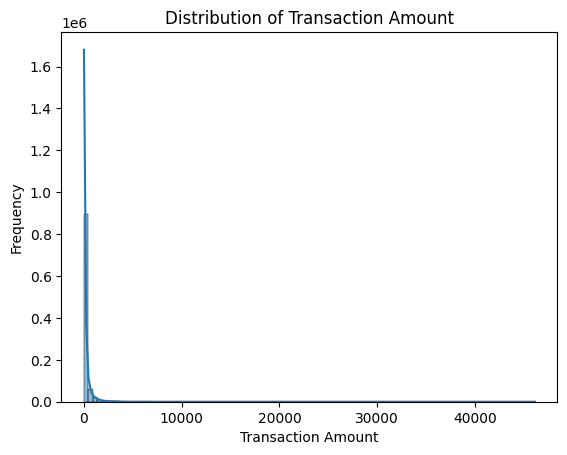

In [13]:
sns.histplot(
    df["transaction_amount"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

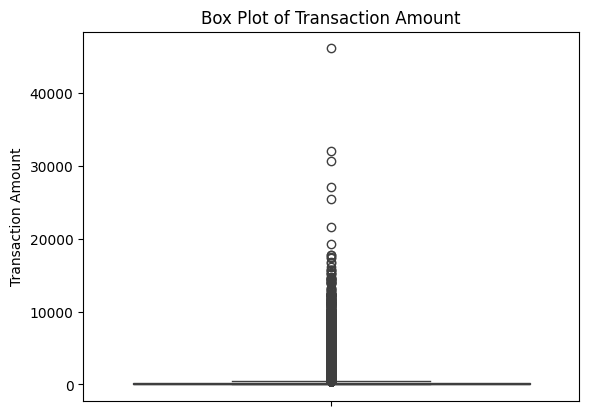

In [14]:
sns.boxplot(
    df["transaction_amount"]
)

plt.ylabel("Transaction Amount")
plt.title("Box Plot of Transaction Amount")

plt.show()

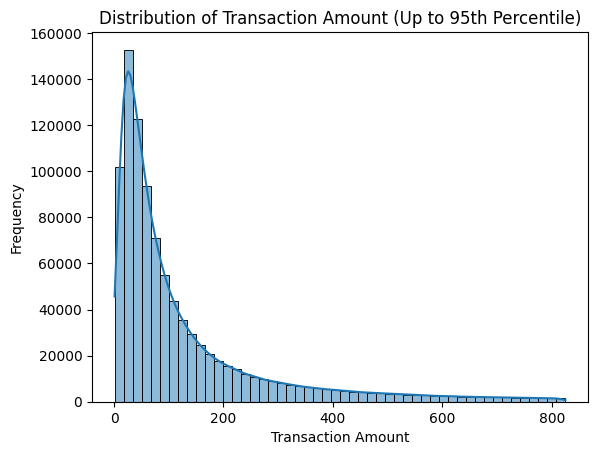

In [15]:
limit = df["transaction_amount"].quantile(0.95)

sns.histplot(
    df[df["transaction_amount"] <= limit]["transaction_amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount (Up to 95th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

##### Observation
- Transaction amounts are highly right-skewed.
- Most transactions are concentrated within the lower transaction range.
- A small number of transactions have exceptionally high values, resulting in numerous outliers.
- The mean transaction amount (204.79) is significantly higher than the median (73.12), indicating the influence of these high-value transactions.

#### Distribution of Account Balance

Account Balance is another financial variable in the dataset. Analyzing its distribution helps identify common balance ranges, detect skewness, and reveal unusually large or small balance amounts that may require further investigation.

##### Analysis Objective
To examine the distribution of account balance amounts, identify potential skewness and outliers, and understand the overall patterns within the dataset.

In [16]:
df["account_balance"].median()

np.float64(8092.12)

In [17]:
df["account_balance"].describe()

count    1000000.00000
mean       16594.25442
std        28171.46068
min          100.00000
25%         3609.01750
50%         8092.12000
75%        18225.02500
max       500000.00000
Name: account_balance, dtype: float64

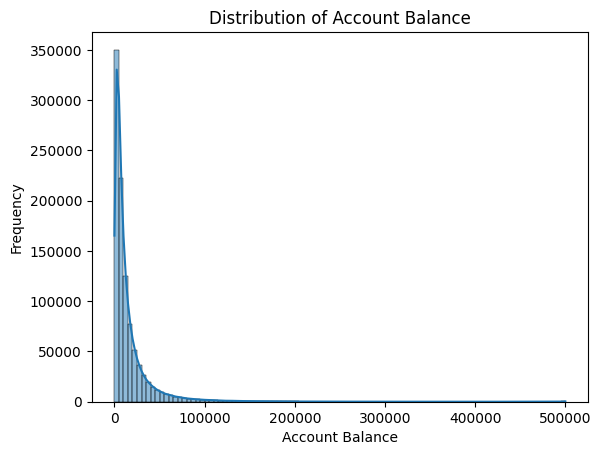

In [18]:
sns.histplot(
    df["account_balance"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Account Balance")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")

plt.show()

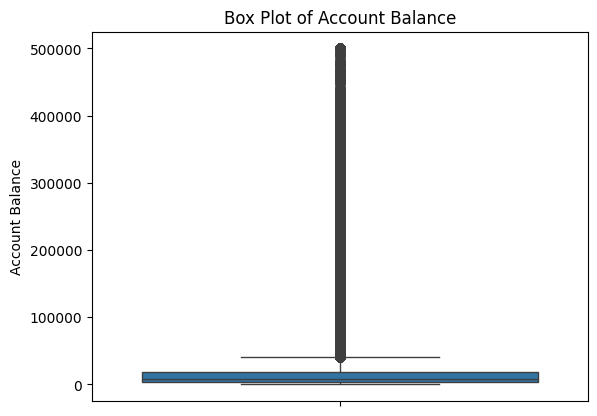

In [19]:
sns.boxplot(
    df["account_balance"]
)

plt.ylabel("Account Balance")
plt.title("Box Plot of Account Balance")

plt.show()

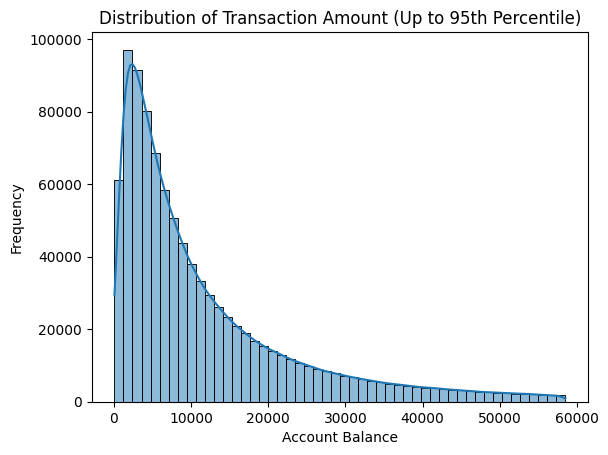

In [20]:
limit = df["account_balance"].quantile(0.95)

sns.histplot(
    df[df["account_balance"] <= limit]["account_balance"],
    bins = 50,
    kde = True
)

plt.xlabel("Account Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount (Up to 95th Percentile)")

plt.show()

##### Observation
- Customer account balances exhibit a positively skewed distribution.
- Most customers maintain relatively modest account balances, while a smaller proportion hold significantly larger balances.
- The mean account balance (16594.25) is considerably higher than the median (8092.12), indicating the influence of high-balance accounts.
- The wide range of values suggests substantial variability in customer account balances.

### CUSTOMER FEATURES

#### Distribution of Customer Age

Customer age is an important demographic feature that provides insight into the composition of the customer base. Analyzing its distribution helps understand the age groups represented in the dataset and identify any unusual patterns or extreme values.

##### Analysis Objective

To examine the distribution of customer ages, identify the predominant age groups, detect potential outliers, and gain an understanding of the overall demographic profile of the customers.

In [21]:
df["customer_age"].median()

np.float64(42.0)

In [22]:
df["customer_age"].describe()

count    1000000.000000
mean          41.771678
std           13.424588
min           18.000000
25%           32.000000
50%           42.000000
75%           51.000000
max           85.000000
Name: customer_age, dtype: float64

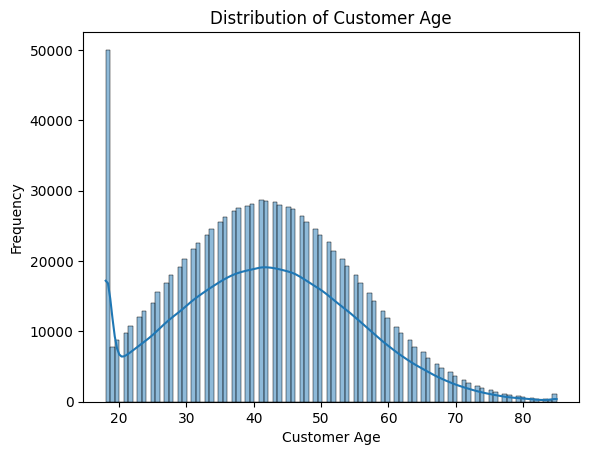

In [23]:
sns.histplot(
    df["customer_age"],
    bins = 100,
    kde = True
)

plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age")

plt.show()

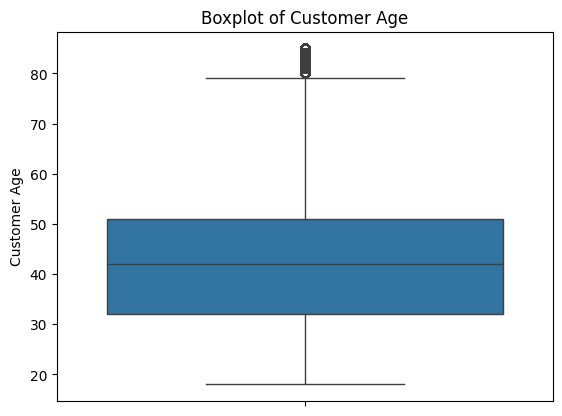

In [24]:
sns.boxplot(
    df["customer_age"]
)

plt.ylabel("Customer Age")
plt.title("Boxplot of Customer Age")

plt.show()

##### Observation

- Customer ages range from **18 to 85 years**, representing an adult customer population.
- The mean age (41.77 years) is nearly identical to the median (42 years), suggesting that the distribution is approximately symmetric.
- The age distribution exhibits moderate variability, with half of the customers falling between **32 and 51 years**.
- No obvious anomalies or unrealistic age values are observed in the dataset.

#### Distribution of Credit Score

Credit score is an important financial indicator that reflects a customer's creditworthiness. Analyzing its distribution helps understand the overall credit profile of customers, identify common credit score ranges, and detect any unusual or extreme values that may warrant further investigation.

##### Analysis Objective

To examine the distribution of customer credit scores, identify the predominant credit score ranges, detect potential outliers, and gain insights into the overall creditworthiness of the customer population.

In [25]:
df["credit_score"].median()

np.float64(680.0)

In [26]:
df["credit_score"].describe()

count    1000000.000000
mean         679.028781
std           78.828748
min          300.000000
25%          625.000000
50%          680.000000
75%          734.000000
max          850.000000
Name: credit_score, dtype: float64

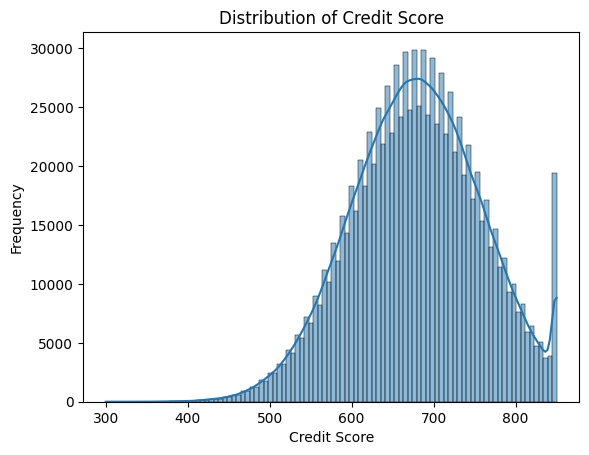

In [27]:
sns.histplot(
    df["credit_score"],
    bins = 100,
    kde = True
)

plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Distribution of Credit Score")

plt.show()

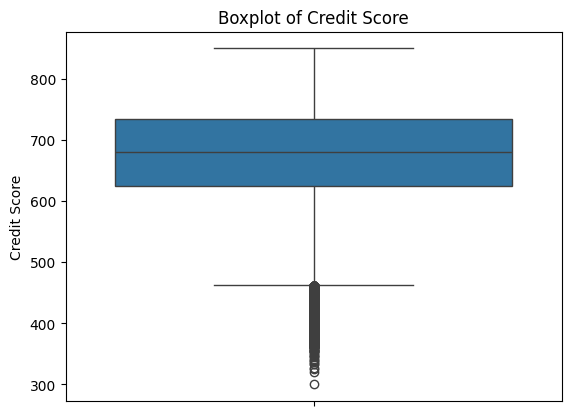

In [28]:
sns.boxplot(
    df["credit_score"]
)

plt.ylabel("Credit Score")
plt.title("Boxplot of Credit Score")

plt.show()

##### Observation

- Customer credit scores range from **300 to 850**, covering the full spectrum of creditworthiness.
- The mean credit score (679.03) is nearly identical to the median (680), indicating an approximately symmetric distribution.
- Half of the customers have credit scores between **625 and 734**, suggesting that most customers fall within a moderate to good credit score range.
- No unrealistic or anomalous credit score values are observed in the dataset.